# Анализ перплексии распределения Qwen по токен-н-граммам
Ноутбук вычисляет перплексию и энтропию двух распределений вероятностей:
- `softmax(mean(logits))` — усредняем логиты, потом softmax
- `mean(softmax(logits))` — softmax для каждого примера, потом усредняем

Н-граммы строятся по **токенам**, а не по словам.

In [19]:
%pip install -q git+https://github.com/huggingface/transformers.git

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Note: you may need to restart the kernel to use updated packages.


In [20]:
import random
import json
import os

import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from tqdm.auto import tqdm
from transformers import AutoTokenizer, AutoModelForCausalLM
from datasets import load_dataset

## Загрузка модели и данных

In [21]:
MODEL_NAME = "Qwen/Qwen3.5-0.8B-Base"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Загрузка модели {MODEL_NAME} на {DEVICE}...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16 if DEVICE == "cuda" else torch.float32,
    device_map="auto" if DEVICE == "cuda" else None,
    trust_remote_code=True
)
model.eval()
print("Модель загружена.")

Загрузка модели Qwen/Qwen3.5-0.8B-Base на cuda...


Loading weights:   0%|          | 0/320 [00:00<?, ?it/s]

Модель загружена.


In [22]:
print("Загрузка датасета...")
ds = load_dataset("gopalkalpande/bbc-news-summary")
texts = [item["Articles"] for item in ds["train"]]
texts = texts[:1000]
print(f"Всего текстов: {len(texts)}")

Загрузка датасета...
Всего текстов: 1000


## Функции для работы с токен-н-граммами

In [23]:
def extract_token_ngrams(texts, tokenizer, n, seed=42):
    """
    Извлекает случайные н-граммы по ТОКЕНАМ из каждого текста.
    
    Каждый текст токенизируется, затем выбирается случайное
    окно из n последовательных токенов, которое декодируется обратно в строку.
    
    Args:
        texts: список исходных текстов
        tokenizer: токенайзер модели
        n: длина н-граммы в токенах
        seed: для воспроизводимости
    
    Returns:
        список строк-н-грамм (декодированных обратно из токенов)
    """
    rng = random.Random(seed)
    ngrams = []
    
    for text in texts:
        # Токенизируем без добавления специальных токенов
        token_ids = tokenizer.encode(text, add_special_tokens=False)
        
        if len(token_ids) < n:
            # Текст слишком короткий — пропускаем
            continue
        
        # Случайное начало окна
        max_start = len(token_ids) - n
        start = rng.randint(0, max_start)
        
        # Срез из n токенов
        window_ids = token_ids[start:start + n]
        
        # Декодируем обратно в текст (это будет промпт для модели)
        ngram_text = tokenizer.decode(window_ids, skip_special_tokens=True)
        ngrams.append(ngram_text)
    
    return ngrams

In [24]:
def compute_entropy(probs, eps=1e-10):
    """
    Вычисляет энтропию (в натах) распределения вероятностей.
    H = -sum(p * log(p))
    """
    probs = torch.clamp(probs, min=eps)
    probs = probs / probs.sum()
    return (-torch.sum(probs * torch.log(probs))).item()


def compute_perplexity(probs, eps=1e-10):
    """
    Вычисляет перплексию через энтропию: PPL = exp(H).
    """
    return np.exp(compute_entropy(probs, eps))

In [25]:
def get_both_distributions(
    model,
    tokenizer,
    prompts,
    batch_size=32
):
    """
    Вычисляет оба распределения и дополнительную статистику для списка промптов.

    Возвращает dict с ключами:
      softmax_of_mean  : softmax(mean(logits))          [V]
      mean_of_softmax  : mean(softmax(logits))           [V]
      var_of_softmax   : var(softmax(logits)) по-поэлементно [V]
                         (дисперсия вероятностей каждого токена по примерам)
      per_example_entropy  : H(softmax(logit_i)) для каждого примера  [N]
      per_example_ppl      : exp(H) для каждого примера               [N]

    Фильтрация токенов НЕ применяется.
    """
    vocab_size = model.lm_head.out_features
    device = model.device

    accumulated_logits  = torch.zeros(vocab_size, device=device)  # sum(logits)
    accumulated_probs   = torch.zeros(vocab_size, device=device)  # sum(p_i)
    accumulated_probs_sq = torch.zeros(vocab_size, device=device) # sum(p_i^2)  — для дисперсии

    per_example_entropy = []  # H для каждого примера
    total = 0

    for i in tqdm(range(0, len(prompts), batch_size), leave=False):
        batch_prompts = prompts[i:i + batch_size]
        inputs = tokenizer(
            batch_prompts,
            return_tensors="pt",
            padding=True,
            truncation=True
        ).to(device)

        with torch.no_grad():
            logits = model(inputs.input_ids, attention_mask=inputs.attention_mask).logits

        # Берём логиты последнего реального токена каждой последовательности
        last_token_idx = inputs.attention_mask.sum(dim=1) - 1
        batch_logits = logits[torch.arange(logits.size(0)), last_token_idx]  # [B, V]

        # Накапливаем для softmax(mean(logits))
        accumulated_logits += batch_logits.sum(dim=0)

        # softmax для каждого примера
        probs = F.softmax(batch_logits, dim=-1)  # [B, V]

        # Накапливаем для mean(softmax) и var(softmax)
        accumulated_probs    += probs.sum(dim=0)       # sum p_i
        accumulated_probs_sq += (probs ** 2).sum(dim=0) # sum p_i^2

        # Попримерная энтропия: H_i = -sum(p * log(p))
        eps = 1e-10
        p_clamped = torch.clamp(probs, min=eps)
        h_batch = -torch.sum(p_clamped * torch.log(p_clamped), dim=-1)  # [B]
        per_example_entropy.append(h_batch.cpu())

        total += len(batch_prompts)

    if total == 0:
        raise ValueError("Нет обработанных примеров.")

    # softmax(mean(logits))
    mean_logits = accumulated_logits / total
    dist_softmax_of_mean = F.softmax(mean_logits, dim=-1).cpu()

    # mean(softmax(logits))
    mean_probs = accumulated_probs / total
    dist_mean_of_softmax = mean_probs.cpu()

    # var(softmax(logits)) = E[p^2] - (E[p])^2
    var_of_softmax = (accumulated_probs_sq / total - mean_probs ** 2).cpu()
    var_of_softmax = torch.clamp(var_of_softmax, min=0.0)  # численная стабильность

    # Собираем попримерную статистику
    all_entropy = torch.cat(per_example_entropy)          # [N]
    all_ppl     = torch.exp(all_entropy)                  # [N]

    return {
        "softmax_of_mean":     dist_softmax_of_mean,
        "mean_of_softmax":     dist_mean_of_softmax,
        "var_of_softmax":      var_of_softmax,
        "per_example_entropy": all_entropy,
        "per_example_ppl":     all_ppl,
    }

## Основной цикл: n от 1 до 100

In [26]:
torch.backends.cudnn.enabled = False  # обход бага Conv1D на некоторых GPU

In [27]:
MIN_N = 1
MAX_N = 60
BATCH_SIZE = 32
SEED = 42

# Директория для сохранения всех данных
OUTPUT_DIR = "results"
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(os.path.join(OUTPUT_DIR, "distributions"), exist_ok=True)
os.makedirs(os.path.join(OUTPUT_DIR, "plots"), exist_ok=True)

# Основные результаты: n -> {entropy, perplexity, mean_var, ...}
results = {
    "softmax_of_mean": {},   # softmax(mean(logits))
    "mean_of_softmax": {},   # mean(softmax(logits))
}

# Данные для боксплотов: n -> np.array попримерных энтропий/перплексий
boxplot_data = {
    "per_example_entropy": {},   # H_i для каждого примера
    "per_example_ppl":     {},   # PPL_i = exp(H_i)
}

print(f"Запуск цикла n = {MIN_N} ... {MAX_N}")
print(f"Результаты сохраняются в ./{OUTPUT_DIR}/")

for n in range(MIN_N, MAX_N + 1):
    print(f"\n--- n={n} ---")

    # 1. Формируем токен-н-граммы
    ngrams = extract_token_ngrams(texts, tokenizer, n, seed=SEED)
    print(f"  Н-грамм: {len(ngrams)}  |  пример: {repr(ngrams[0][:80])}")

    if len(ngrams) == 0:
        print("  Пропускаем (нет данных)")
        continue

    # 2. Вычисляем распределения и дополнительную статистику
    stats = get_both_distributions(model, tokenizer, ngrams, batch_size=BATCH_SIZE)

    dist_som = stats["softmax_of_mean"]
    dist_mos = stats["mean_of_softmax"]
    var_mos  = stats["var_of_softmax"]       # дисперсия softmax по примерам [V]
    pe_ent   = stats["per_example_entropy"]  # H_i [N]
    pe_ppl   = stats["per_example_ppl"]      # PPL_i [N]

    # 3. Агрегированные метрики для обоих методов
    for name, dist in [("softmax_of_mean", dist_som), ("mean_of_softmax", dist_mos)]:
        H   = compute_entropy(dist)
        PPL = compute_perplexity(dist)
        results[name][n] = {"entropy": H, "perplexity": PPL}

    # Дополнительно: средняя дисперсия вероятностей по всему словарю
    mean_var = var_mos.mean().item()
    results["mean_of_softmax"][n]["mean_token_variance"] = mean_var

    print(
        f"  [softmax(mean)]  H={results['softmax_of_mean'][n]['entropy']:.4f}  "
        f"PPL={results['softmax_of_mean'][n]['perplexity']:.2f}"
    )
    print(
        f"  [mean(softmax)]  H={results['mean_of_softmax'][n]['entropy']:.4f}  "
        f"PPL={results['mean_of_softmax'][n]['perplexity']:.2f}  "
        f"mean_var={mean_var:.2e}"
    )

    # 4. Попримерные данные для боксплотов
    boxplot_data["per_example_entropy"][n] = pe_ent.float().numpy()
    boxplot_data["per_example_ppl"][n]     = pe_ppl.float().numpy()

    # 5. Сохраняем сами распределения (для воспроизводимости)
    torch.save(
        {
            "softmax_of_mean":     dist_som,
            "mean_of_softmax":     dist_mos,
            "var_of_softmax":      var_mos,
            "per_example_entropy": pe_ent,
            "per_example_ppl":     pe_ppl,
        },
        os.path.join(OUTPUT_DIR, "distributions", f"dist_n{n:03d}.pt")
    )

print("\n✓ Цикл завершён.")

Запуск цикла n = 1 ... 60
Результаты сохраняются в ./results/

--- n=1 ---
  Н-грамм: 1000  |  пример: '.'


  0%|          | 0/32 [00:00<?, ?it/s]

  [softmax(mean)]  H=7.9939  PPL=2962.72
  [mean(softmax)]  H=7.8761  PPL=2633.51  mean_var=1.97e-07

--- n=2 ---
  Н-грамм: 1000  |  пример: '-election giveaway'


  0%|          | 0/32 [00:00<?, ?it/s]

  [softmax(mean)]  H=7.5222  PPL=1848.57
  [mean(softmax)]  H=7.7116  PPL=2234.08  mean_var=2.84e-07

--- n=3 ---
  Н-грамм: 1000  |  пример: '-election giveaway,'


...

  [softmax(mean)]  H=6.1881  PPL=486.94
  [mean(softmax)]  H=6.9591  PPL=1052.65  mean_var=9.00e-07

--- n=59 ---
  Н-грамм: 1000  |  пример: '-election giveaway, but Mr Brown is thought to have about £2bn to spare...- Incr'


  0%|          | 0/32 [00:00<?, ?it/s]

  [softmax(mean)]  H=6.2699  PPL=528.45
  [mean(softmax)]  H=7.0026  PPL=1099.50  mean_var=9.03e-07

--- n=60 ---
  Н-грамм: 1000  |  пример: '-election giveaway, but Mr Brown is thought to have about £2bn to spare...- Incr'


  0%|          | 0/32 [00:00<?, ?it/s]

  [softmax(mean)]  H=6.2311  PPL=508.33
  [mean(softmax)]  H=6.9754  PPL=1069.93  mean_var=9.16e-07

✓ Цикл завершён.


## Сохранение сводных результатов (JSON + numpy)

In [28]:
# Сохраняем JSON для удобного чтения
with open(os.path.join(OUTPUT_DIR, "results.json"), "w", encoding="utf-8") as f:
    json.dump(results, f, ensure_ascii=False, indent=2)

# Собираем массивы
ns = sorted(results["softmax_of_mean"].keys())

entropy_som  = np.array([results["softmax_of_mean"][n]["entropy"]             for n in ns])
ppl_som      = np.array([results["softmax_of_mean"][n]["perplexity"]          for n in ns])
entropy_mos  = np.array([results["mean_of_softmax"][n]["entropy"]             for n in ns])
ppl_mos      = np.array([results["mean_of_softmax"][n]["perplexity"]          for n in ns])
mean_var_mos = np.array([results["mean_of_softmax"][n]["mean_token_variance"] for n in ns])

# Попримерные данные для боксплотов (raggedy — разный размер при разных n)
# Сохраняем как object-array
bp_entropy_arr = np.empty(len(ns), dtype=object)
bp_ppl_arr     = np.empty(len(ns), dtype=object)
for i, n in enumerate(ns):
    bp_entropy_arr[i] = boxplot_data["per_example_entropy"][n]
    bp_ppl_arr[i]     = boxplot_data["per_example_ppl"][n]

np.savez(
    os.path.join(OUTPUT_DIR, "metrics.npz"),
    ns=ns,
    entropy_softmax_of_mean=entropy_som,
    ppl_softmax_of_mean=ppl_som,
    entropy_mean_of_softmax=entropy_mos,
    ppl_mean_of_softmax=ppl_mos,
    mean_token_variance=mean_var_mos,
)
# Боксплот-данные — отдельным файлом (object arrays)
np.save(os.path.join(OUTPUT_DIR, "boxplot_entropy.npy"), bp_entropy_arr, allow_pickle=True)
np.save(os.path.join(OUTPUT_DIR, "boxplot_ppl.npy"),     bp_ppl_arr,     allow_pickle=True)

print(f"Сохранено: {OUTPUT_DIR}/results.json")
print(f"Сохранено: {OUTPUT_DIR}/metrics.npz")
print(f"Сохранено: {OUTPUT_DIR}/boxplot_entropy.npy  (объект-массив попримерных H)")
print(f"Сохранено: {OUTPUT_DIR}/boxplot_ppl.npy      (объект-массив попримерных PPL)")

Сохранено: results/results.json
Сохранено: results/metrics.npz
Сохранено: results/boxplot_entropy.npy  (объект-массив попримерных H)
Сохранено: results/boxplot_ppl.npy      (объект-массив попримерных PPL)


## Графики

### 1. Распределения вероятностей (пример для одного n)

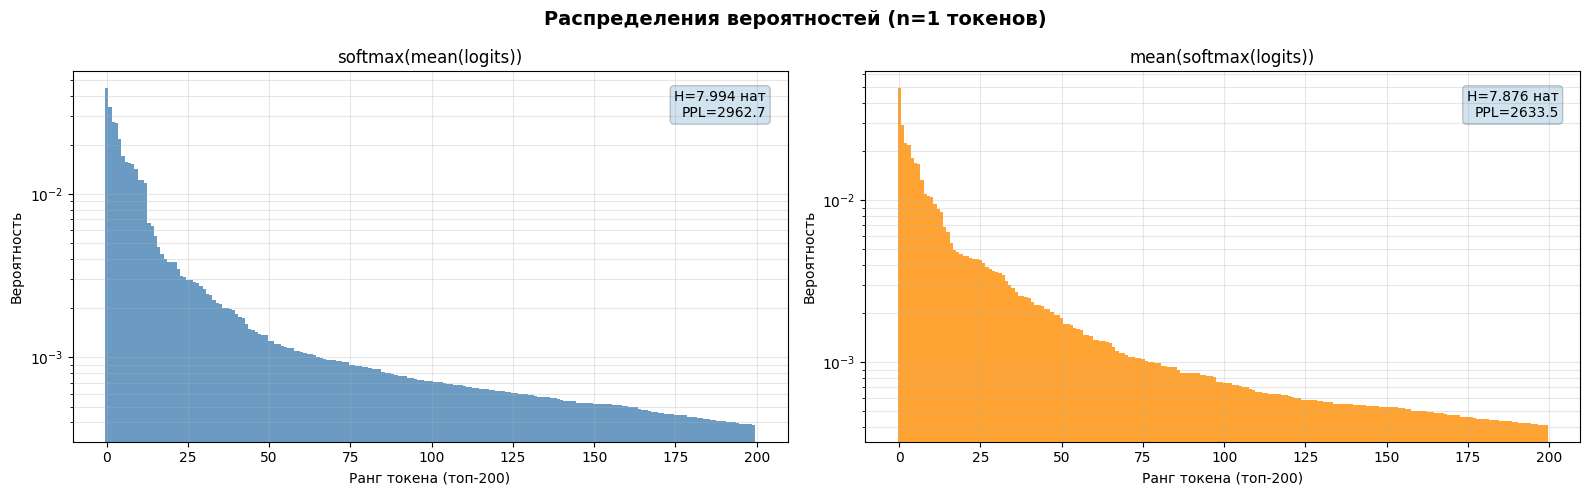

Сохранено: results/plots/dist_comparison_n001.png


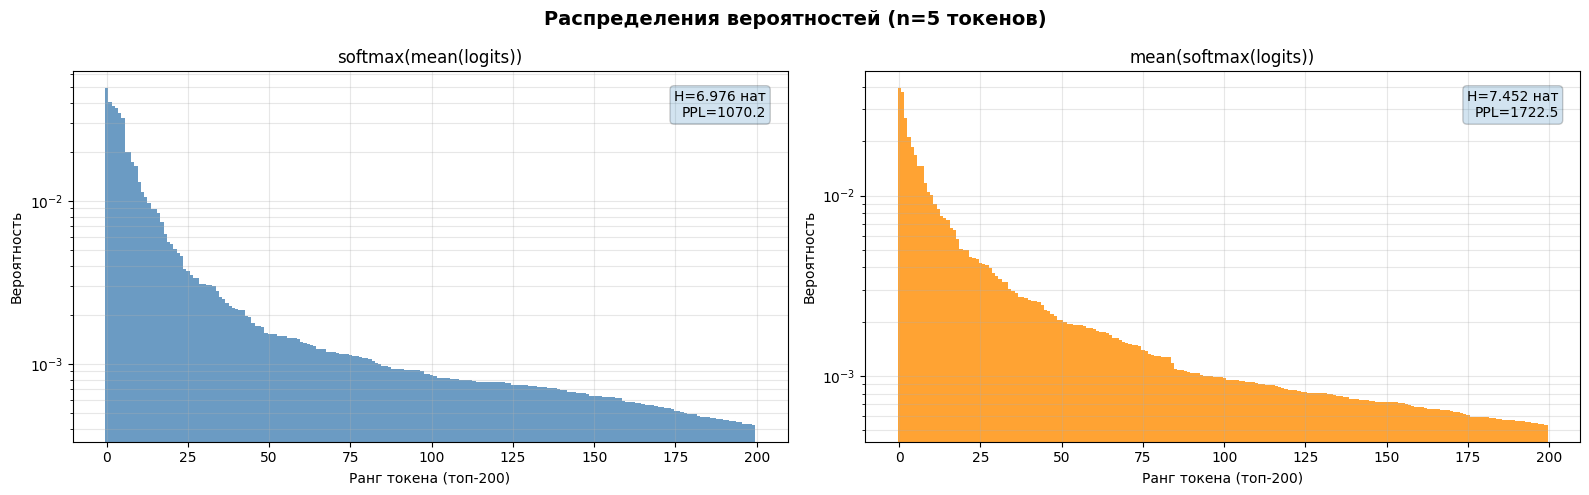

Сохранено: results/plots/dist_comparison_n005.png


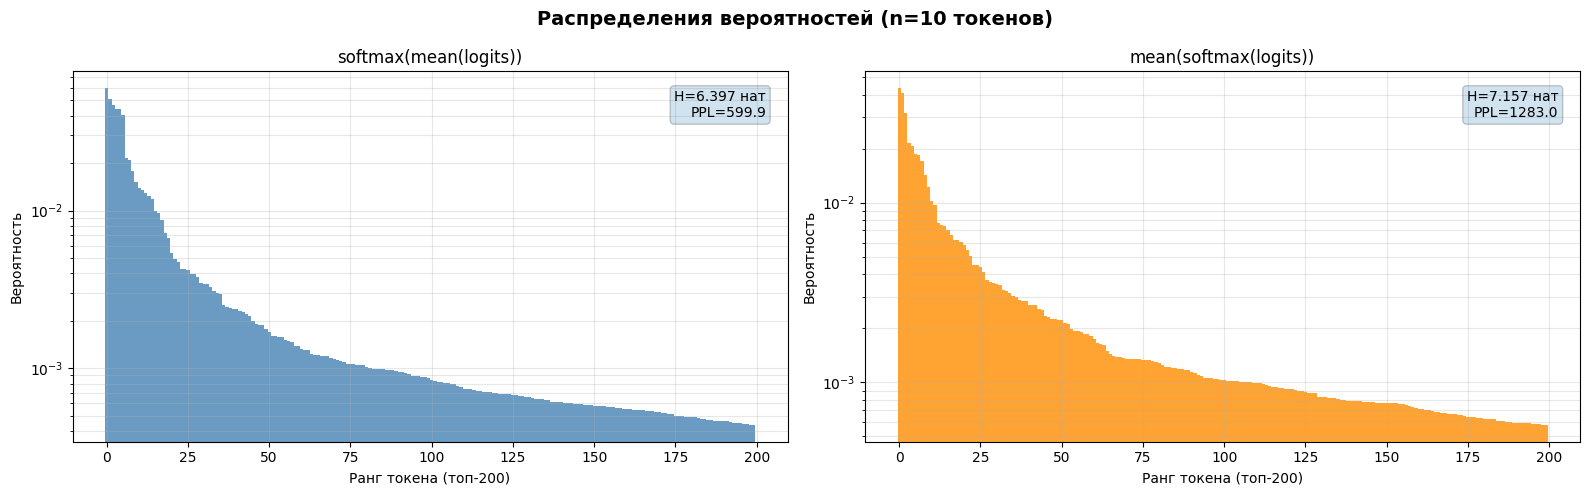

Сохранено: results/plots/dist_comparison_n010.png


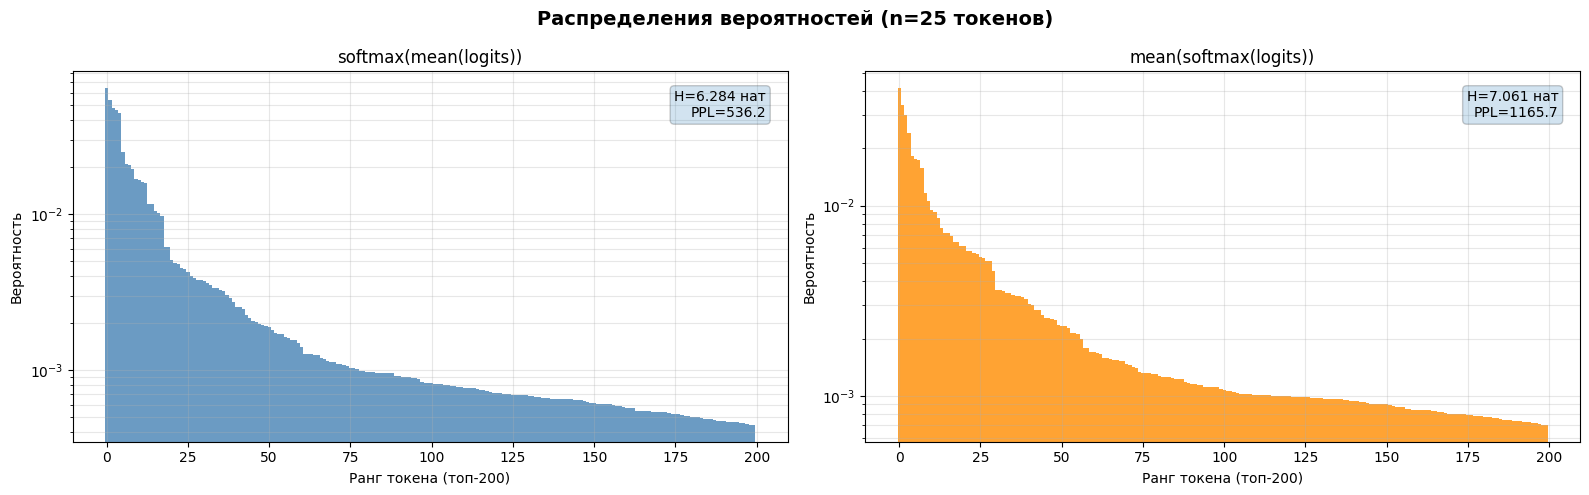

Сохранено: results/plots/dist_comparison_n025.png


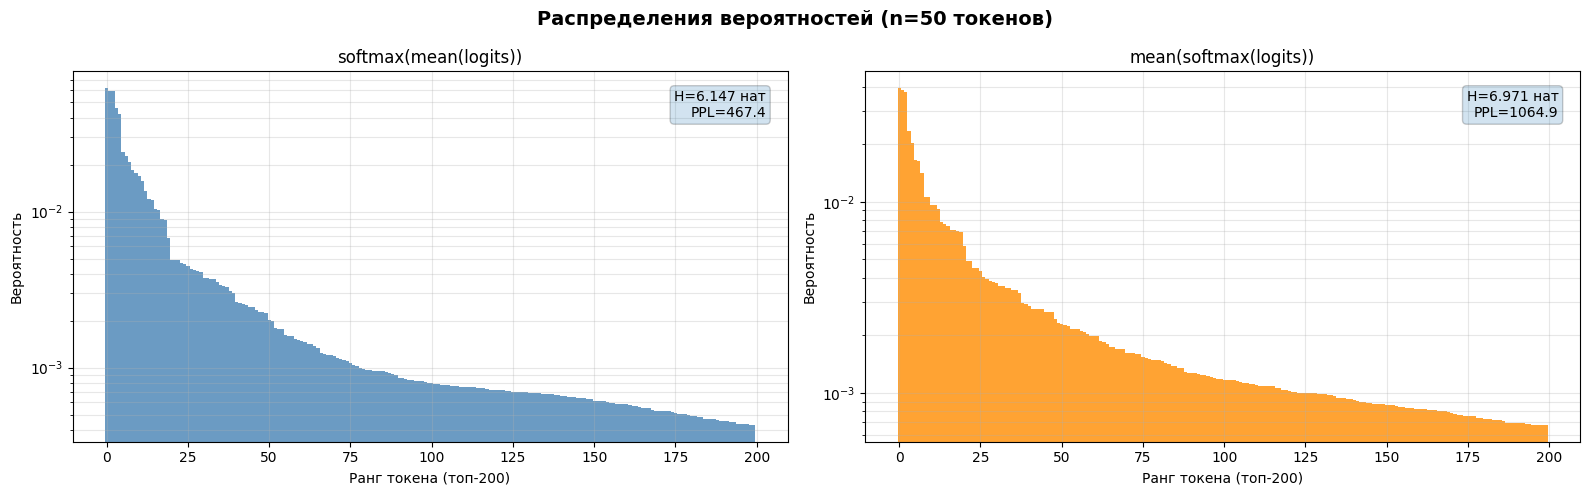

Сохранено: results/plots/dist_comparison_n050.png


In [29]:
def plot_distributions_for_n(n, output_dir=OUTPUT_DIR):
    """
    Загружает сохранённые распределения для заданного n и строит
    сравнительный график softmax(mean(logits)) vs mean(softmax(logits)).
    """
    path = os.path.join(output_dir, "distributions", f"dist_n{n:03d}.pt")
    data = torch.load(path, map_location="cpu")
    dist_som = data["softmax_of_mean"].numpy()
    dist_mos = data["mean_of_softmax"].numpy()

    # Сортируем по убыванию для наглядности
    sorted_som = np.sort(dist_som)[::-1].copy()
    sorted_mos = np.sort(dist_mos)[::-1].copy()

    TOP_K = 200  # отображаем топ-K токенов

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle(f"Распределения вероятностей (n={n} токенов)", fontsize=14, fontweight="bold")

    for ax, dist_sorted, label, color in [
        (axes[0], sorted_som, "softmax(mean(logits))", "steelblue"),
        (axes[1], sorted_mos, "mean(softmax(logits))", "darkorange"),
    ]:
        ax.bar(range(TOP_K), dist_sorted[:TOP_K], color=color, alpha=0.8, width=1.0)
        ax.set_title(label, fontsize=12)
        ax.set_xlabel(f"Ранг токена (топ-{TOP_K})", fontsize=10)
        ax.set_ylabel("Вероятность", fontsize=10)
        ax.set_yscale("log")
        H = compute_entropy(torch.tensor(dist_sorted))
        PPL = np.exp(H)
        ax.text(0.97, 0.95, f"H={H:.3f} нат\nPPL={PPL:.1f}",
                transform=ax.transAxes, va="top", ha="right",
                fontsize=10, bbox=dict(boxstyle="round", alpha=0.2))
        ax.grid(True, alpha=0.3, which="both")

    plt.tight_layout()
    save_path = os.path.join(output_dir, "plots", f"dist_comparison_n{n:03d}.png")
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Сохранено: {save_path}")


# Строим для нескольких репрезентативных значений n
for n_show in [1, 5, 10, 25, 50, 100]:
    if n_show in ns:
        plot_distributions_for_n(n_show)

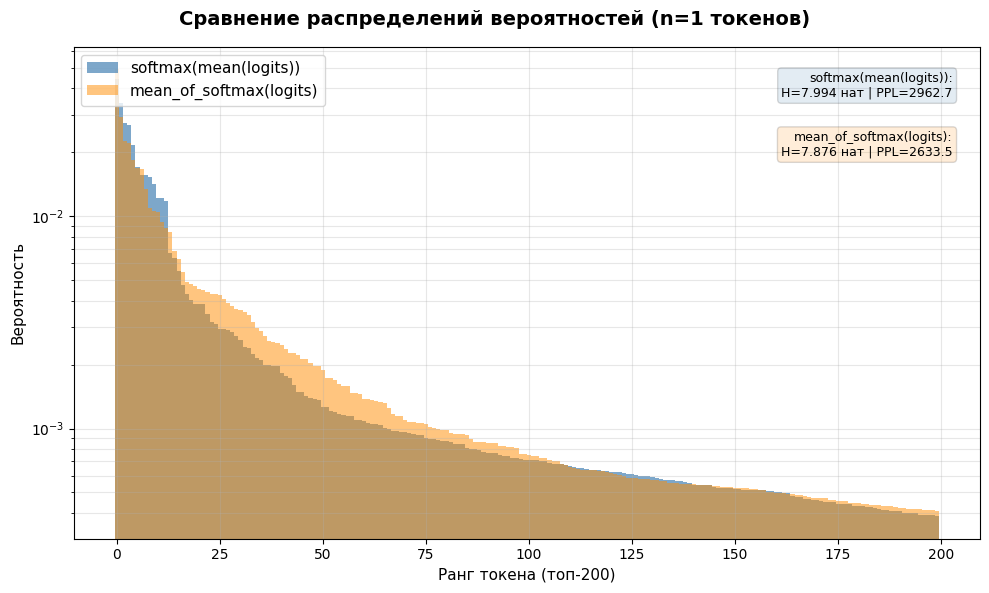

Сохранено: results/plots/dist_combined_n001.png


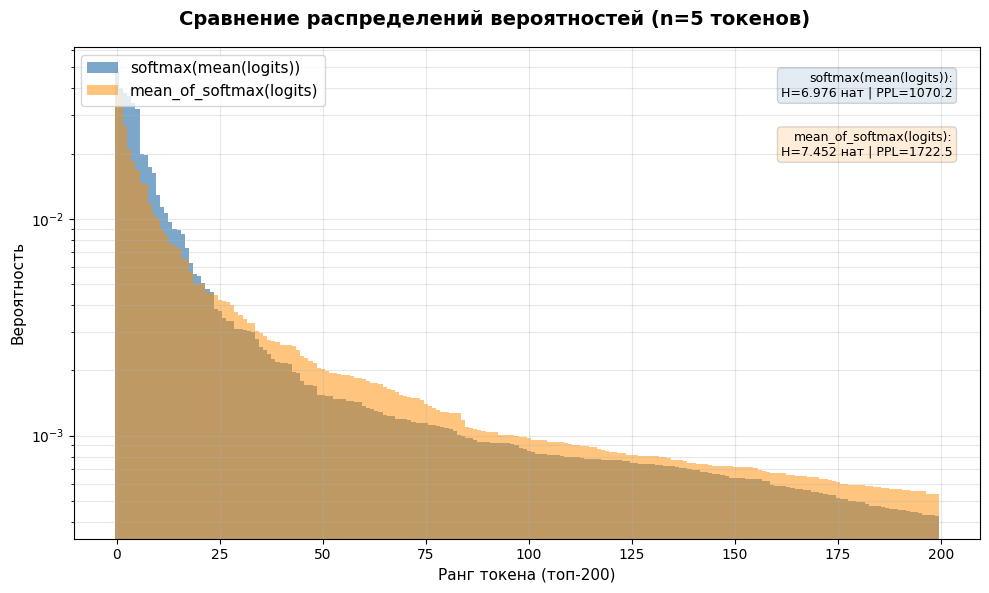

Сохранено: results/plots/dist_combined_n005.png


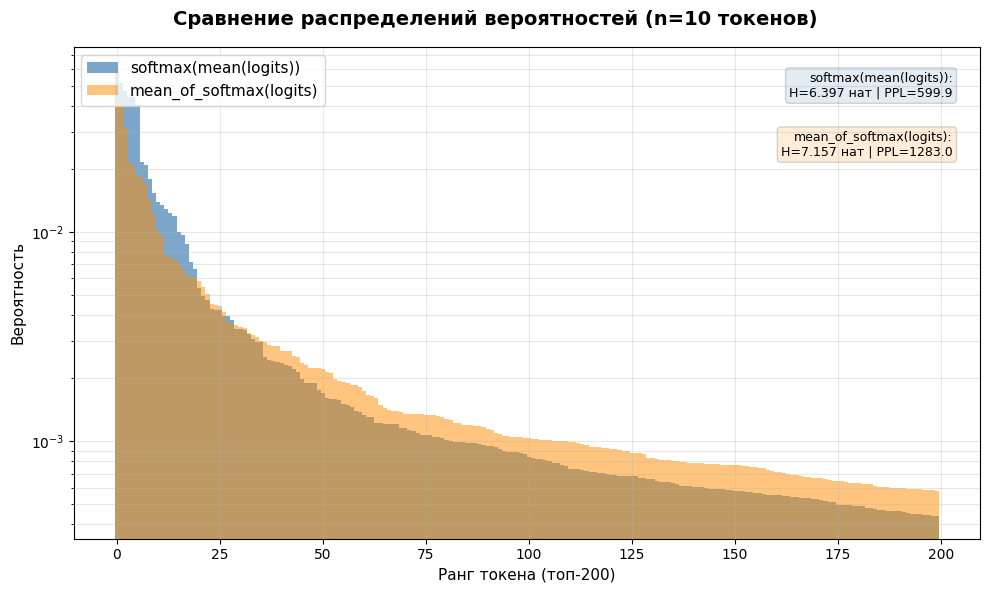

Сохранено: results/plots/dist_combined_n010.png


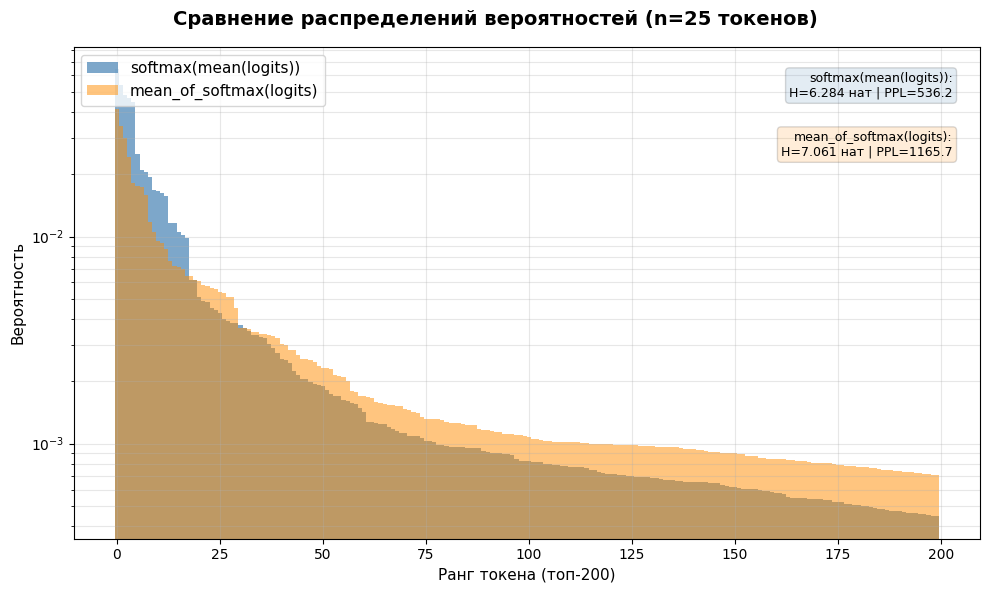

Сохранено: results/plots/dist_combined_n025.png


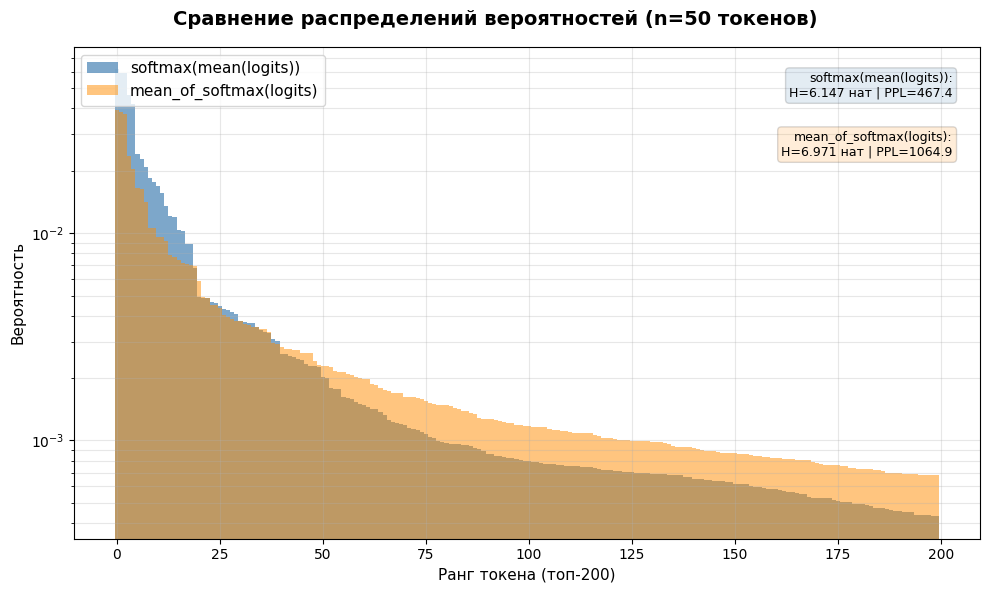

Сохранено: results/plots/dist_combined_n050.png


In [38]:
def plot_distributions_for_n(n, output_dir=OUTPUT_DIR):
    """
    Загружает сохранённые распределения для заданного n и строит
    совмещенный график softmax(mean(logits)) vs mean(softmax(logits)) на одной оси.
    """
    path = os.path.join(output_dir, "distributions", f"dist_n{n:03d}.pt")
    data = torch.load(path, map_location="cpu")
    dist_som = data["softmax_of_mean"].numpy()
    dist_mos = data["mean_of_softmax"].numpy()

    # Сортируем по убыванию для наглядности
    sorted_som = np.sort(dist_som)[::-1].copy()
    sorted_mos = np.sort(dist_mos)[::-1].copy()

    TOP_K = 200  # отображаем топ-K токенов

    # Создаем ОДИН график вместо двух сабплотов
    fig, ax = plt.subplots(figsize=(10, 6))
    fig.suptitle(f"Сравнение распределений вероятностей (n={n} токенов)", fontsize=14, fontweight="bold")

    # Данные для итерации и отрисовки
    plots_data = [
        (sorted_som, "softmax(mean(logits))", "steelblue", 0.7),
        (sorted_mos, "mean_of_softmax(logits)", "darkorange", 0.5) # чуть больше прозрачности для наложения
    ]

    # Смещение для текста метрик, чтобы они не перекрывали друг друга
    y_text_pos = 0.95 
    
    for dist_sorted, label, color, alpha in plots_data:
        # Рисуем бары на одной и той же оси `ax`
        ax.bar(range(TOP_K), dist_sorted[:TOP_K], color=color, alpha=alpha, width=1.0, label=label)
        
        # Считаем метрики
        H = compute_entropy(torch.tensor(dist_sorted))
        PPL = np.exp(H)
        
        # Выводим плашки с метриками друг под другом
        ax.text(0.97, y_text_pos, f"{label}:\nH={H:.3f} нат | PPL={PPL:.1f}",
                transform=ax.transAxes, va="top", ha="right",
                fontsize=9, bbox=dict(boxstyle="round", facecolor=color, alpha=0.15))
        y_text_pos -= 0.12 # двигаем позицию следующего текста вниз

    # Настройки единственной оси
    ax.set_xlabel(f"Ранг токена (топ-{TOP_K})", fontsize=11)
    ax.set_ylabel("Вероятность", fontsize=11)
    ax.set_yscale("log")
    ax.grid(True, alpha=0.3, which="both")
    
    # Добавляем легенду, чтобы различать цвета
    ax.legend(loc="upper left", fontsize=11)

    plt.tight_layout()
    save_path = os.path.join(output_dir, "plots", f"dist_combined_n{n:03d}.png")
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Сохранено: {save_path}")

# Строим для нескольких репрезентативных значений n
for n_show in [1, 5, 10, 25, 50, 100]:
    if n_show in ns:
        plot_distributions_for_n(n_show)

### 2. Энтропия и перплексия vs n (оба метода на одном графике)

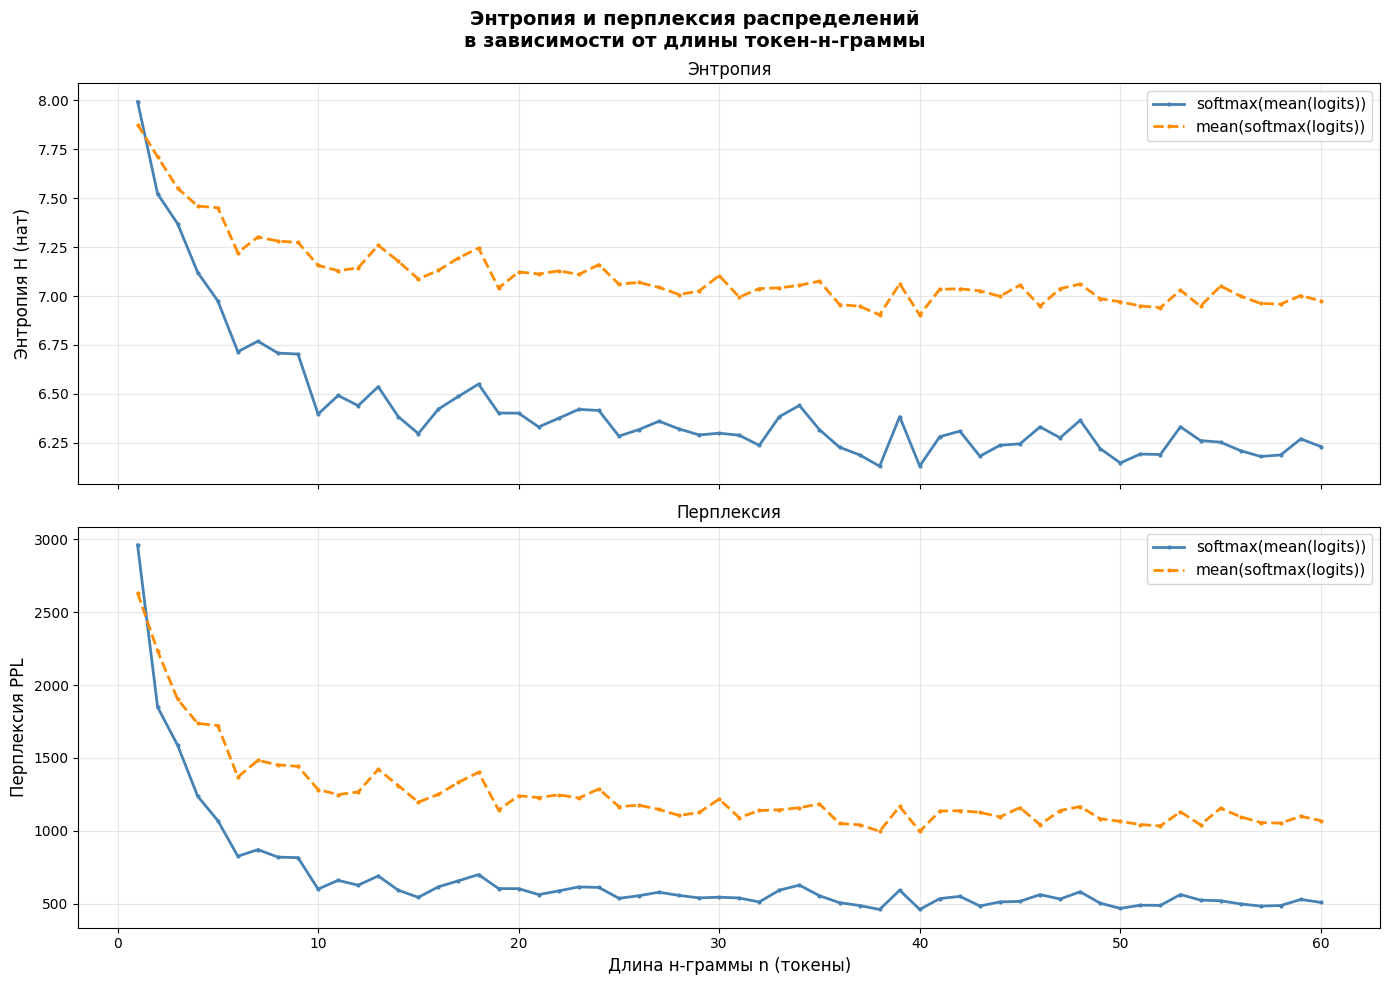

Сохранено: results/plots/entropy_perplexity_vs_n.png


In [30]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
fig.suptitle(
    "Энтропия и перплексия распределений\n"
    "в зависимости от длины токен-н-граммы",
    fontsize=14, fontweight="bold"
)

# ── Энтропия ──────────────────────────────────────────────────────────────────
ax_h = axes[0]
ax_h.plot(ns, entropy_som, color="steelblue",   linewidth=2,
          label="softmax(mean(logits))", marker=".", markersize=4)
ax_h.plot(ns, entropy_mos, color="darkorange",  linewidth=2,
          label="mean(softmax(logits))",  marker=".", markersize=4, linestyle="--")
ax_h.set_ylabel("Энтропия H (нат)", fontsize=12)
ax_h.legend(fontsize=11)
ax_h.grid(True, alpha=0.3)
ax_h.set_title("Энтропия", fontsize=12)

# ── Перплексия ────────────────────────────────────────────────────────────────
ax_p = axes[1]
ax_p.plot(ns, ppl_som, color="steelblue",  linewidth=2,
          label="softmax(mean(logits))", marker=".", markersize=4)
ax_p.plot(ns, ppl_mos, color="darkorange", linewidth=2,
          label="mean(softmax(logits))",  marker=".", markersize=4, linestyle="--")
ax_p.set_ylabel("Перплексия PPL", fontsize=12)
ax_p.set_xlabel("Длина н-граммы n (токены)", fontsize=12)
ax_p.legend(fontsize=11)
ax_p.grid(True, alpha=0.3)
ax_p.set_title("Перплексия", fontsize=12)

plt.tight_layout()
save_path = os.path.join(OUTPUT_DIR, "plots", "entropy_perplexity_vs_n.png")
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Сохранено: {save_path}")

### 3. Дисперсия вероятностей mean(softmax(logits)) vs n

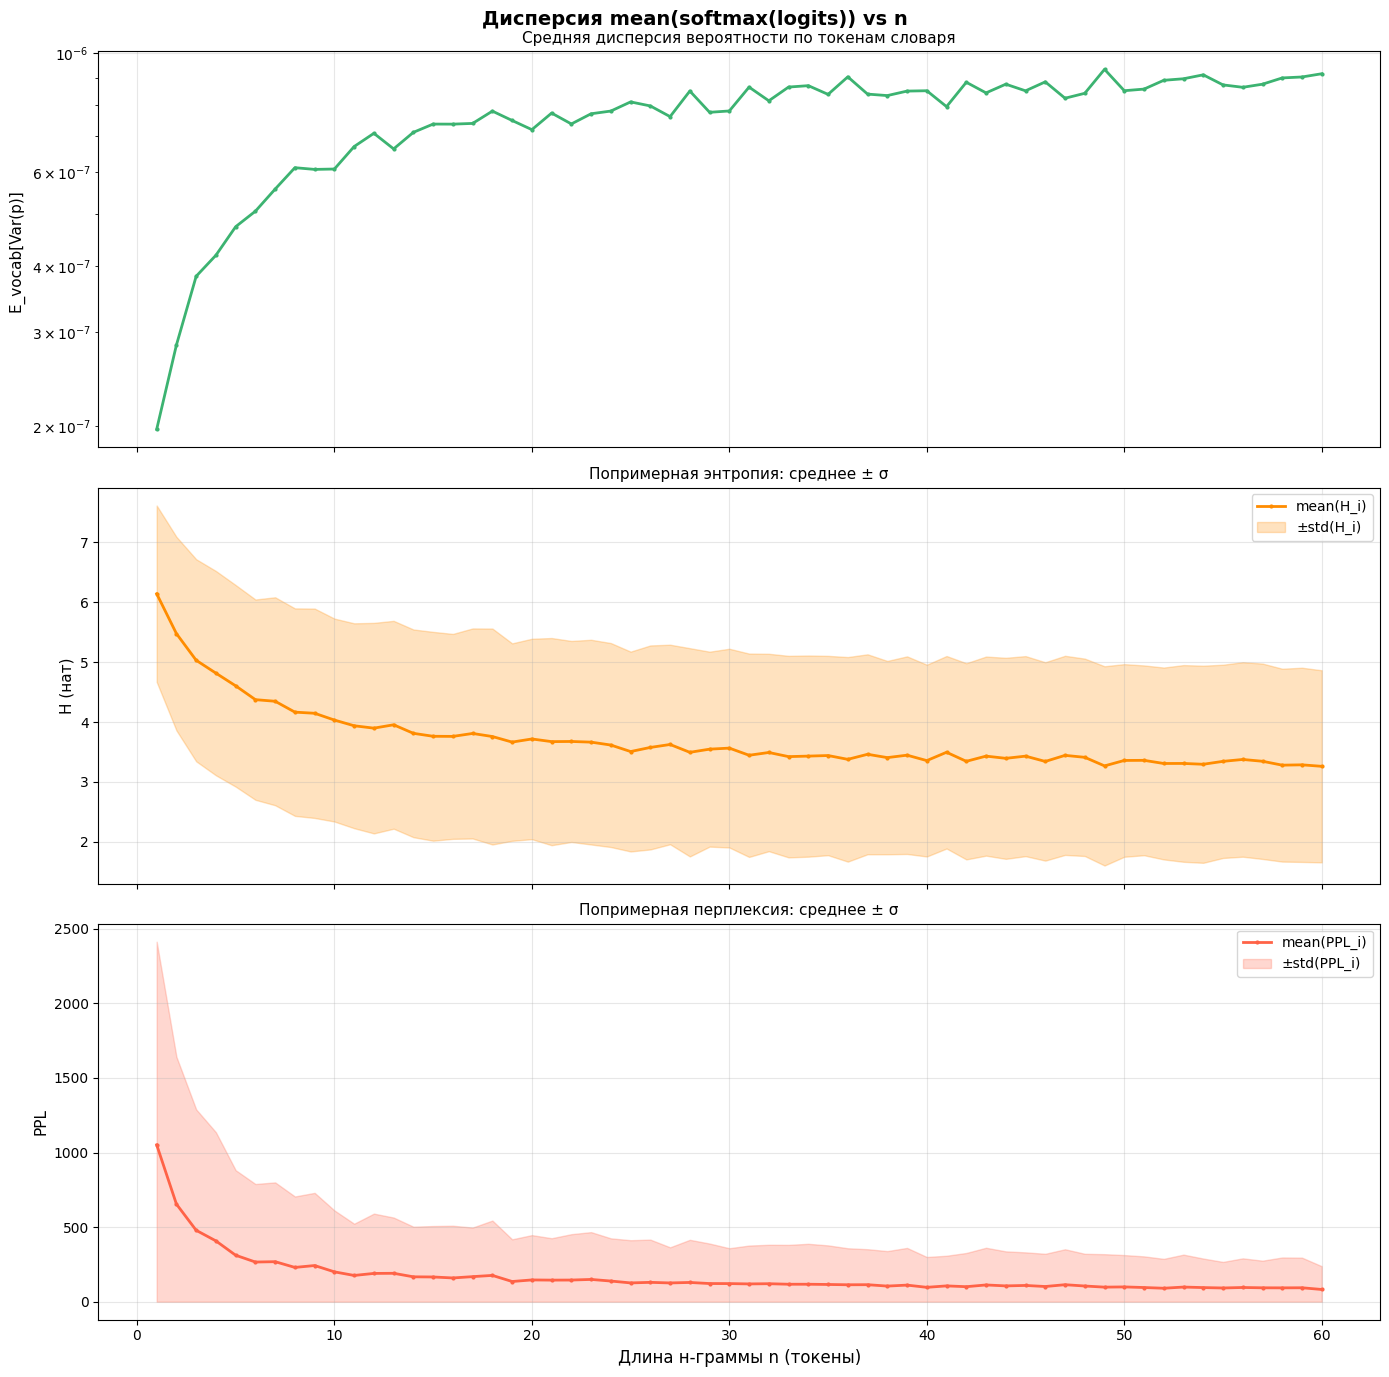

Сохранено: results/plots/variance_vs_n.png


In [31]:
# mean_var_mos — средняя дисперсия по всем токенам словаря для каждого n
# Дополнительно считаем std(H_i) — разброс попримерных энтропий
std_entropy_mos = np.array([np.std(boxplot_data["per_example_entropy"][n]) for n in ns])
std_ppl_mos     = np.array([np.std(boxplot_data["per_example_ppl"][n])     for n in ns])

fig, axes = plt.subplots(3, 1, figsize=(14, 14), sharex=True)
fig.suptitle(
    "Дисперсия mean(softmax(logits)) vs n",
    fontsize=14, fontweight="bold"
)

# (а) Средняя дисперсия вероятностей токенов (E_vocab[Var_examples[p(tok)]])
ax = axes[0]
ax.plot(ns, mean_var_mos, color="mediumseagreen", linewidth=2, marker=".", markersize=4)
ax.set_ylabel("E_vocab[Var(p)] ", fontsize=11)
ax.set_title("Средняя дисперсия вероятности по токенам словаря", fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_yscale("log")

# (б) mean(H) ± std(H) — среднее и разброс попримерных энтропий
mean_ent = np.array([np.mean(boxplot_data["per_example_entropy"][n]) for n in ns])
ax = axes[1]
ax.plot(ns, mean_ent, color="darkorange", linewidth=2, marker=".", markersize=4, label="mean(H_i)")
ax.fill_between(ns,
                mean_ent - std_entropy_mos,
                mean_ent + std_entropy_mos,
                alpha=0.25, color="darkorange", label="±std(H_i)")
ax.set_ylabel("H (нат)", fontsize=11)
ax.set_title("Попримерная энтропия: среднее ± σ", fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# (в) mean(PPL) ± std(PPL)
mean_ppl_pe = np.array([np.mean(boxplot_data["per_example_ppl"][n]) for n in ns])
ax = axes[2]
ax.plot(ns, mean_ppl_pe, color="tomato", linewidth=2, marker=".", markersize=4, label="mean(PPL_i)")
ax.fill_between(ns,
                np.maximum(0, mean_ppl_pe - std_ppl_mos),
                mean_ppl_pe + std_ppl_mos,
                alpha=0.25, color="tomato", label="±std(PPL_i)")
ax.set_ylabel("PPL", fontsize=11)
ax.set_xlabel("Длина н-граммы n (токены)", fontsize=12)
ax.set_title("Попримерная перплексия: среднее ± σ", fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
save_path = os.path.join(OUTPUT_DIR, "plots", "variance_vs_n.png")
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Сохранено: {save_path}")

### 4. Боксплоты попримерной энтропии и перплексии vs n

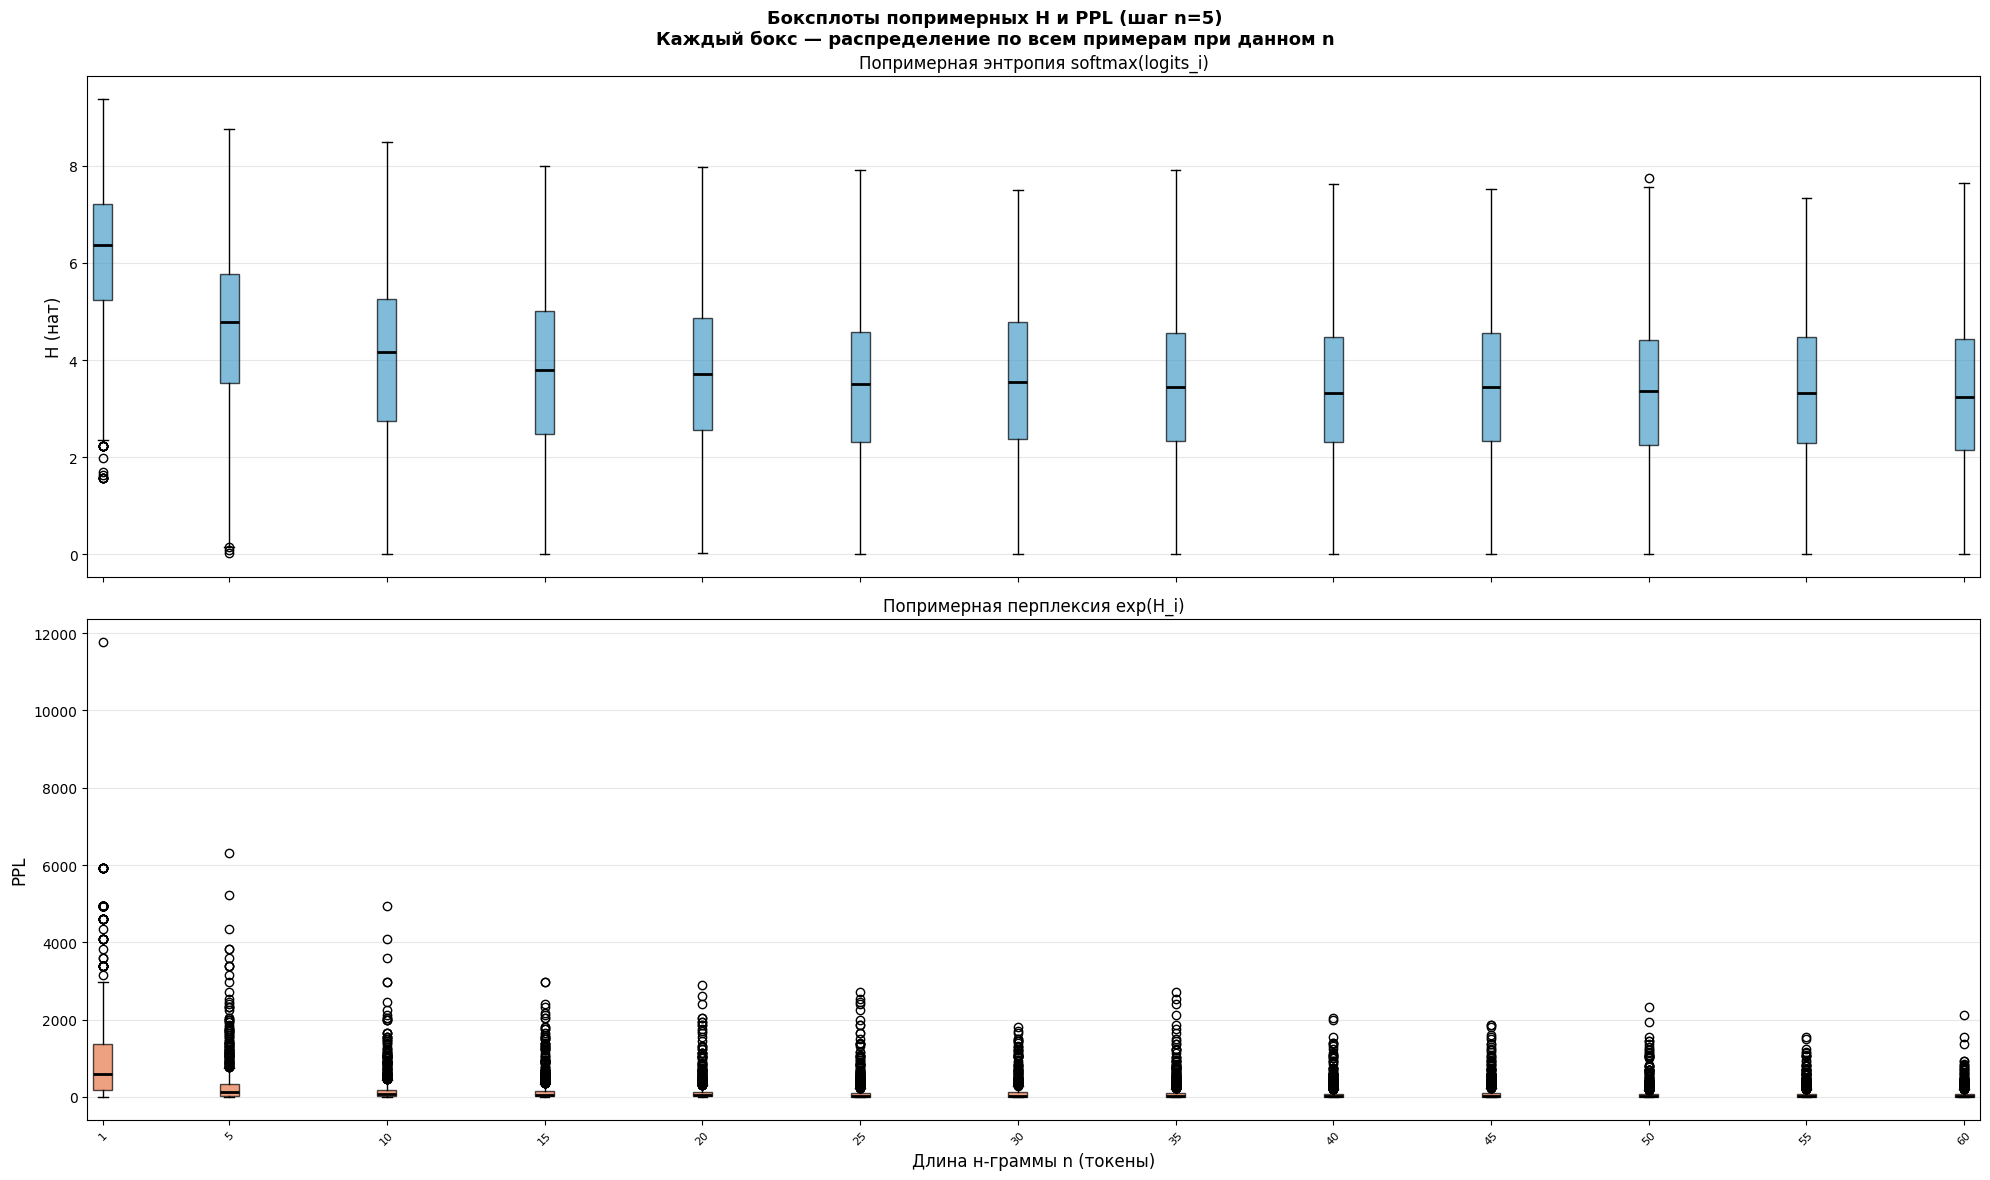

Сохранено: results/plots/boxplots_entropy_ppl_vs_n.png


In [32]:
# Боксплоты строим для subset значений n, чтобы не перегружать ось X
# Можно менять шаг: step=1 даёт все 100 боксов
BOXPLOT_STEP = 5   # каждые 5 токенов
ns_box = [n for n in ns if n % BOXPLOT_STEP == 0 or n == 1]

entropy_box_data = [boxplot_data["per_example_entropy"][n] for n in ns_box]
ppl_box_data     = [boxplot_data["per_example_ppl"][n]     for n in ns_box]

fig, axes = plt.subplots(2, 1, figsize=(20, 12), sharex=True)
fig.suptitle(
    f"Боксплоты попримерных H и PPL (шаг n={BOXPLOT_STEP})\n"
    "Каждый бокс — распределение по всем примерам при данном n",
    fontsize=13, fontweight="bold"
)

bp_props = dict(widths=0.6, patch_artist=True, notch=False,
                medianprops=dict(color="black", linewidth=2))

# ── Энтропия ──────────────────────────────────────────────────────────────────
ax = axes[0]
bp = ax.boxplot(entropy_box_data, positions=ns_box, **bp_props)
for patch in bp["boxes"]:
    patch.set_facecolor("#4a9eca")
    patch.set_alpha(0.7)
ax.set_ylabel("H (нат)", fontsize=12)
ax.set_title("Попримерная энтропия softmax(logits_i)", fontsize=12)
ax.grid(True, alpha=0.3, axis="y")

# ── Перплексия ────────────────────────────────────────────────────────────────
ax = axes[1]
bp = ax.boxplot(ppl_box_data, positions=ns_box, **bp_props)
for patch in bp["boxes"]:
    patch.set_facecolor("#e87a4a")
    patch.set_alpha(0.7)
ax.set_ylabel("PPL", fontsize=12)
ax.set_xlabel("Длина н-граммы n (токены)", fontsize=12)
ax.set_title("Попримерная перплексия exp(H_i)", fontsize=12)
ax.grid(True, alpha=0.3, axis="y")

# Подписи на оси X только для отображаемых n
for ax in axes:
    ax.set_xticks(ns_box)
    ax.set_xticklabels([str(n) for n in ns_box], fontsize=8, rotation=45)

plt.tight_layout()
save_path = os.path.join(OUTPUT_DIR, "plots", "boxplots_entropy_ppl_vs_n.png")
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Сохранено: {save_path}")

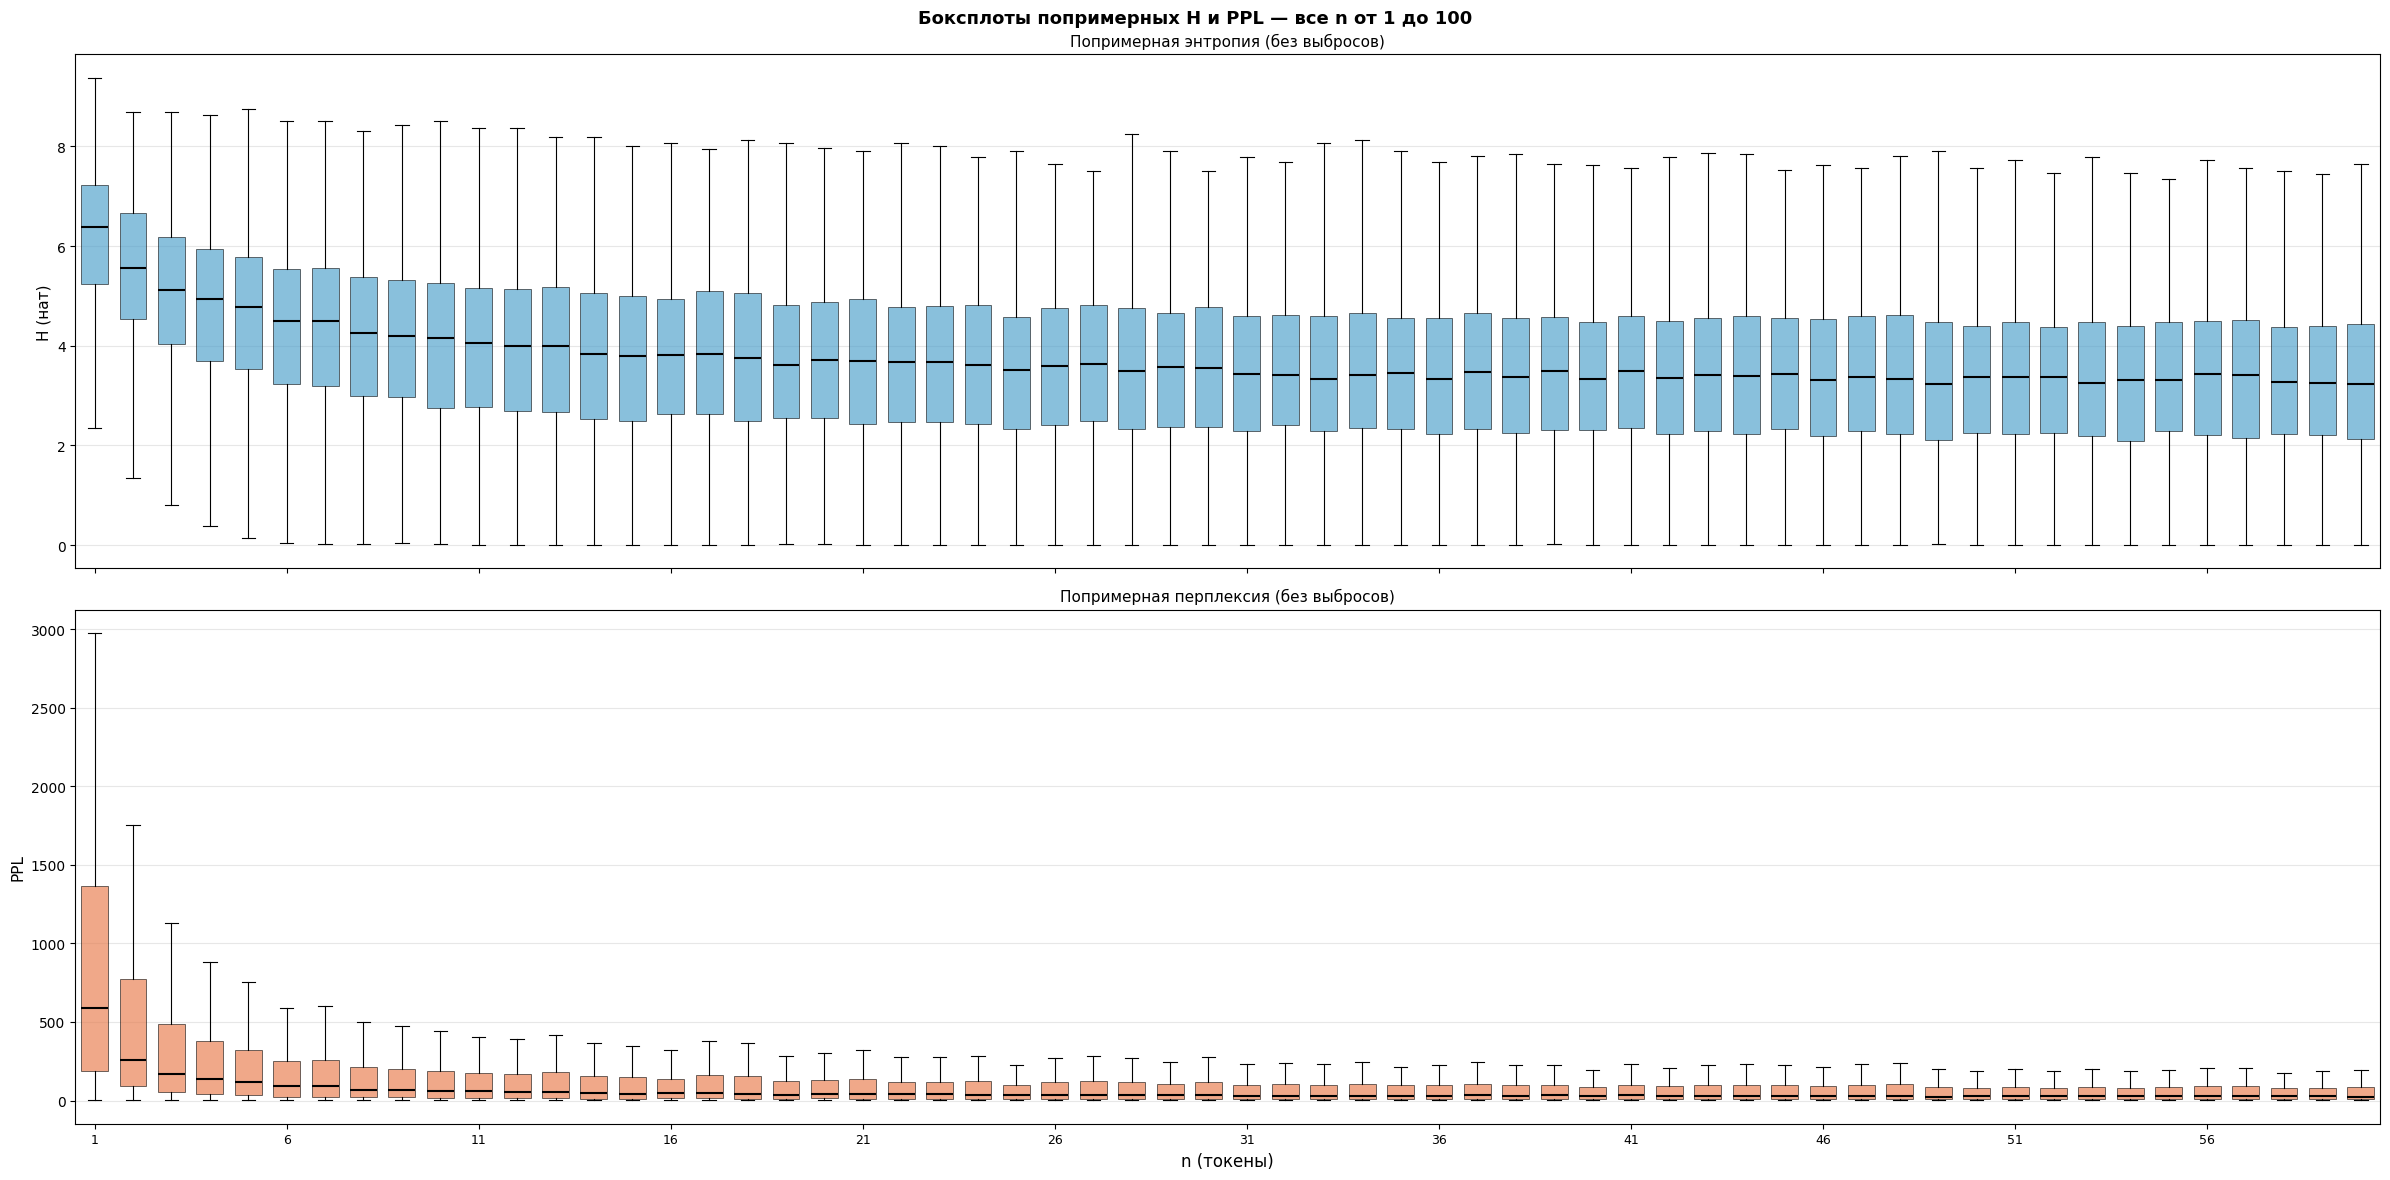

Сохранено: results/plots/boxplots_all_n_dense.png


In [33]:
# Плотные боксплоты (шаг 1) — все 100 значений n
# Удобно для общего обзора тренда
entropy_all = [boxplot_data["per_example_entropy"][n] for n in ns]
ppl_all     = [boxplot_data["per_example_ppl"][n]     for n in ns]

fig, axes = plt.subplots(2, 1, figsize=(24, 12), sharex=True)
fig.suptitle(
    "Боксплоты попримерных H и PPL — все n от 1 до 100",
    fontsize=13, fontweight="bold"
)

bp_props_dense = dict(
    widths=0.7,
    patch_artist=True,
    notch=False,
    showfliers=False,   # без выбросов — иначе очень шумно
    medianprops=dict(color="black", linewidth=1.5),
    whiskerprops=dict(linewidth=0.8),
    capprops=dict(linewidth=0.8),
    boxprops=dict(linewidth=0.6),
)

for ax, data_list, color, ylabel, title in [
    (axes[0], entropy_all, "#4a9eca", "H (нат)",
     "Попримерная энтропия (без выбросов)"),
    (axes[1], ppl_all,     "#e87a4a", "PPL",
     "Попримерная перплексия (без выбросов)"),
]:
    bp = ax.boxplot(data_list, positions=ns, **bp_props_dense)
    for patch in bp["boxes"]:
        patch.set_facecolor(color)
        patch.set_alpha(0.65)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontsize=11)
    ax.grid(True, alpha=0.3, axis="y")

axes[1].set_xlabel("n (токены)", fontsize=12)
tick_positions = list(range(1, max(ns) + 1, 5))
for ax in axes:
    ax.set_xticks(tick_positions)
    ax.set_xticklabels([str(t) for t in tick_positions], fontsize=9)

plt.tight_layout()
save_path = os.path.join(OUTPUT_DIR, "plots", "boxplots_all_n_dense.png")
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Сохранено: {save_path}")

### 5. Разница между методами

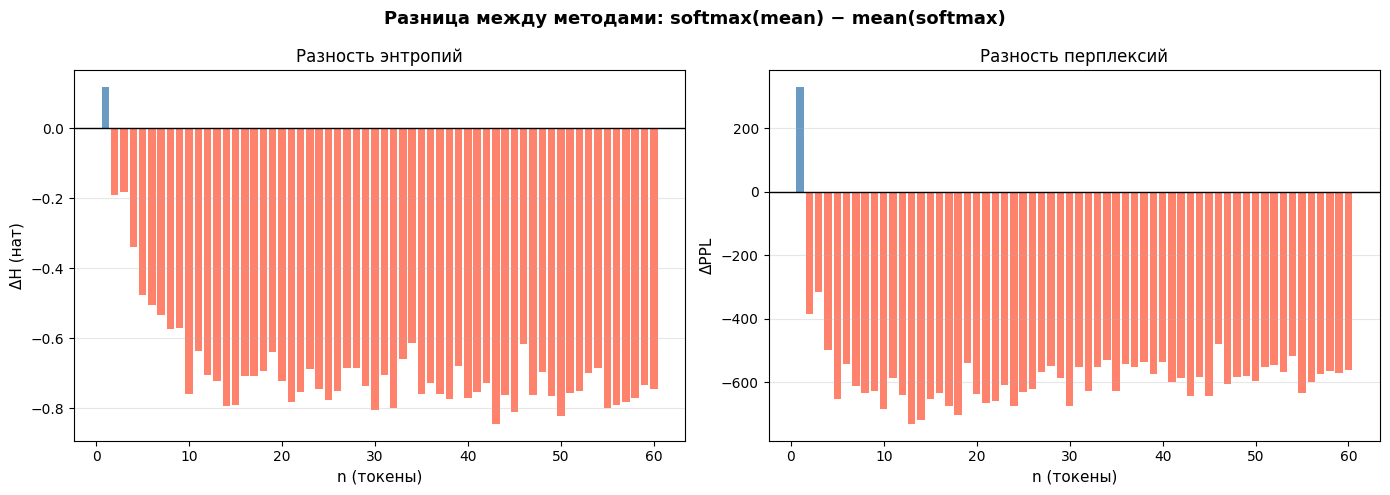

Сохранено: results/plots/diff_between_methods.png


In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    "Разница между методами: softmax(mean) − mean(softmax)",
    fontsize=13, fontweight="bold"
)

diff_entropy = entropy_som - entropy_mos
diff_ppl     = ppl_som     - ppl_mos

for ax, diff, ylabel, title in [
    (axes[0], diff_entropy, "ΔH (нат)",  "Разность энтропий"),
    (axes[1], diff_ppl,     "ΔPPL",       "Разность перплексий"),
]:
    colors = ["steelblue" if d >= 0 else "tomato" for d in diff]
    ax.bar(ns, diff, color=colors, alpha=0.8, width=0.8)
    ax.axhline(0, color="black", linewidth=1)
    ax.set_xlabel("n (токены)", fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
save_path = os.path.join(OUTPUT_DIR, "plots", "diff_between_methods.png")
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Сохранено: {save_path}")

## Итоговая таблица

In [35]:
import pandas as pd

std_entropy_arr = np.array([np.std(boxplot_data["per_example_entropy"][n]) for n in ns])
std_ppl_arr     = np.array([np.std(boxplot_data["per_example_ppl"][n])     for n in ns])

df = pd.DataFrame({
    "n":                    ns,
    "H  softmax(mean)": entropy_som.round(4),
    "PPL softmax(mean)": ppl_som.round(2),
    "H  mean(softmax)": entropy_mos.round(4),
    "PPL mean(softmax)": ppl_mos.round(2),
    "std(H_i)": std_entropy_arr.round(4),
    "std(PPL_i)": std_ppl_arr.round(2),
    "mean_token_var": mean_var_mos,
})

df_path = os.path.join(OUTPUT_DIR, "results_table.csv")
df.to_csv(df_path, index=False)
print(f"Сохранено: {df_path}")
print()
print(df.to_string(index=False))

Сохранено: results/results_table.csv

 n  H  softmax(mean)  PPL softmax(mean)  H  mean(softmax)  PPL mean(softmax)  std(H_i)  std(PPL_i)  mean_token_var
 1            7.9939            2962.72            7.8761            2633.51    1.4712 1361.650024    1.974686e-07
 2            7.5222            1848.57            7.7116            2234.08    1.6146  987.700012    2.841353e-07
 3            7.3691            1586.26            7.5507            1902.04    1.6855  810.570007    3.822408e-07
 4            7.1202            1236.64            7.4598            1736.76    1.7040  728.390015    4.185434e-07
 5            6.9756            1070.16            7.4515            1722.49    1.6812  570.169983    4.734037e-07
 6            6.7156             825.19            7.2218            1368.89    1.6707  523.159973    5.061717e-07
 7            6.7693             870.67            7.3020            1483.21    1.7346  531.520020    5.568610e-07
 8            6.7085             819.37   

## Что сохранено

| Путь | Описание |
|------|----------|
| `results/results.json` | Все метрики (H, PPL, mean_token_variance) для обоих методов при каждом n |
| `results/metrics.npz` | То же в numpy-формате + массив mean_token_variance |
| `results/results_table.csv` | Сводная таблица с std(H_i), std(PPL_i), mean_token_var |
| `results/boxplot_entropy.npy` | Object-array попримерных H_i для каждого n (для боксплотов) |
| `results/boxplot_ppl.npy` | Object-array попримерных PPL_i для каждого n |
| `results/distributions/dist_n???.pt` | Полные распределения + var_of_softmax + per_example_{entropy,ppl} |
| `results/plots/dist_comparison_n???.png` | Графики распределений для выбранных n |
| `results/plots/entropy_perplexity_vs_n.png` | Энтропия и перплексия vs n (оба метода) |
| `results/plots/variance_vs_n.png` | Дисперсия + mean±std попримерных H и PPL vs n |
| `results/plots/boxplots_entropy_ppl_vs_n.png` | Боксплоты (шаг 5) |
| `results/plots/boxplots_all_n_dense.png` | Плотные боксплоты (все n 1–100) |
| `results/plots/diff_between_methods.png` | Разность между методами |

### Воспроизведение без повторного прогона модели
```python
import numpy as np
import torch

# Агрегированные метрики
data = np.load("results/metrics.npz")
ns            = data["ns"]
entropy_som   = data["entropy_softmax_of_mean"]
ppl_som       = data["ppl_softmax_of_mean"]
entropy_mos   = data["entropy_mean_of_softmax"]
ppl_mos       = data["ppl_mean_of_softmax"]
mean_var_mos  = data["mean_token_variance"]

# Боксплот-данные
bp_entropy = np.load("results/boxplot_entropy.npy", allow_pickle=True)  # [100] object
bp_ppl     = np.load("results/boxplot_ppl.npy",     allow_pickle=True)
# bp_entropy[i] — np.array H_i для n = ns[i]

# Полные данные для n=10
d = torch.load("results/distributions/dist_n010.pt")
dist_som  = d["softmax_of_mean"]      # [V]
dist_mos  = d["mean_of_softmax"]      # [V]
var_mos   = d["var_of_softmax"]       # [V]
pe_ent    = d["per_example_entropy"]  # [N]
pe_ppl    = d["per_example_ppl"]      # [N]
```

In [39]:
import shutil

# Путь к папке, которую нужно запаковать (например, в /kaggle/working/)
dir_to_zip = '/kaggle/working/results'

# Имя и путь итогового архива (создаст my_archive.zip)
output_filename = '/kaggle/working/my_archive'

# Создаем zip-архив
shutil.make_archive(output_filename, 'zip', dir_to_zip)

'/kaggle/working/my_archive.zip'